# Hotel Booking Cancellation Prediction
## Revenue Management with Machine Learning Classification

**Author:** Group 1 MiBA

**Subject:** Artificial Intelligence II


**Dataset:** Hotel Booking Demand — Antonio, Almeida & Nunes (2019), *Data in Brief*, Vol. 22  
**Kaggle Source:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand  
**DOI:** 10.1016/j.dib.2018.11.126

---

### Objective
Binary classification task: predict whether a hotel booking will be **cancelled (1)** or **not (0)** using 119,390 bookings across two hotel types (City Hotel, Resort Hotel).

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Exploratory Data Analysis

In [ ]:
df = pd.read_csv('hotel_bookings.csv')
print(f'Full dataset shape: {df.shape}')

# --- Computational Efficiency: 30% Stratified Sample ---
# The full dataset has 119,390 rows. Training all models (especially SVM with
# probability=True and RandomizedSearchCV) on the full set takes ~2 hours.
# A 30% stratified sample (~35,800 rows) preserves class balance and cuts
# runtime to ~20 minutes while keeping results statistically meaningful.
df = (
    df.groupby('is_canceled', group_keys=False)
      .apply(lambda x: x.sample(frac=0.30, random_state=42))
      .reset_index(drop=True)
)
print(f'Sampled dataset shape (30% stratified): {df.shape}')
print(f'Cancellation rate preserved: {df["is_canceled"].mean()*100:.1f}%')
print(f'\nColumn names:')
print(df.columns.tolist())

In [3]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
          Missing Count  Missing %
company          112593      94.31
agent             16340      13.69
country             488       0.41
children              4       0.00


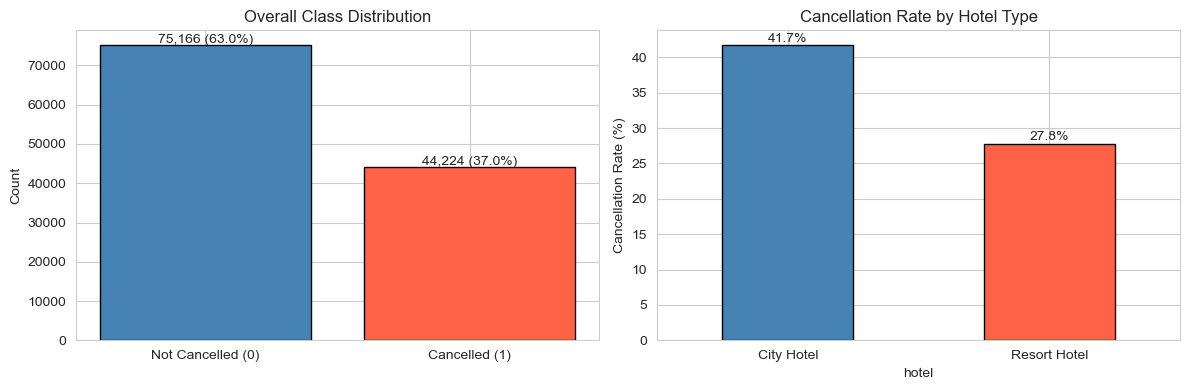


Overall cancellation rate: 37.0%


In [6]:
# Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cancel_counts = df['is_canceled'].value_counts()
axes[0].bar(['Not Cancelled (0)', 'Cancelled (1)'], cancel_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(cancel_counts.values):
    axes[0].text(i, v + 500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')

cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
cancel_by_hotel.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(cancel_by_hotel.index, rotation=0)
for i, v in enumerate(cancel_by_hotel.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()
print(f'\nOverall cancellation rate: {df["is_canceled"].mean()*100:.1f}%')

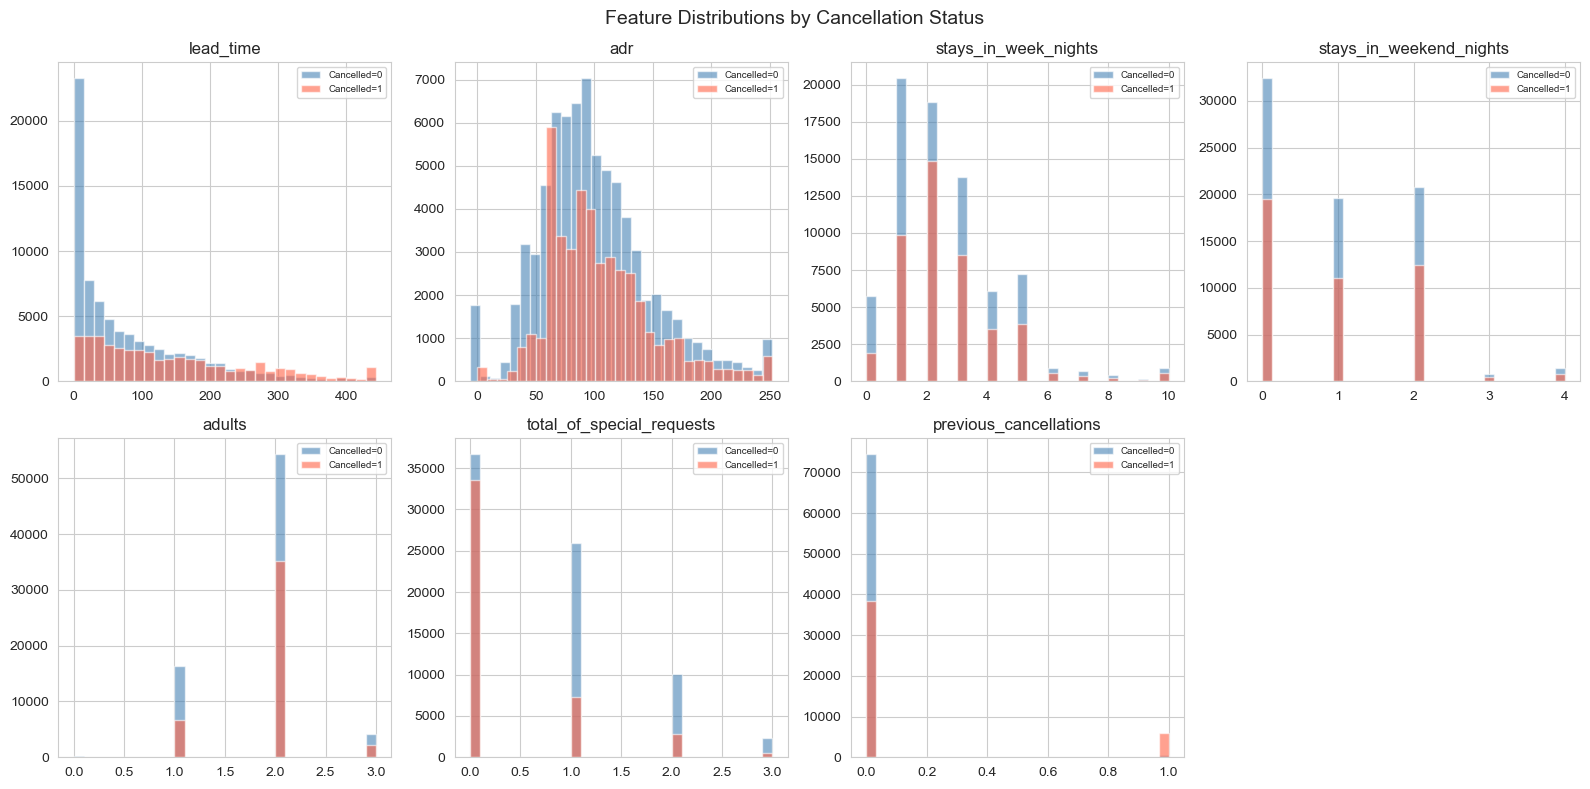

In [7]:
# Distributions of key numeric features
numeric_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                'adults', 'total_of_special_requests', 'previous_cancellations']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df[df['is_canceled'] == label][col].clip(upper=df[col].quantile(0.99)),
                     bins=30, alpha=0.6, color=color,
                     label=f'Cancelled={label}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Cancellation Status', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

### Fix 1: Drop post-hoc leakage columns
- `reservation_status` is a direct restatement of the target — dropped
- `reservation_status_date` is only populated after the event — dropped

### Fix 2: Recover agent/company instead of dropping
- Fill NaN with 0 (no agent / no company)

### Fix 3: Proper one-hot encoding of all nominal categoricals
- `country` grouped by frequency (rare → 'Other') then one-hot encoded
- All other nominal columns: one-hot encoded

In [8]:
# Work on a copy
data = df.copy()

# --- Fix 1: Drop post-hoc leakage columns ---
# reservation_status mirrors is_canceled; reservation_status_date is post-event
data.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)
print('Dropped leakage columns: reservation_status, reservation_status_date')

# --- Drop rows with null 'children' (only 4 rows) ---
data.dropna(subset=['children'], inplace=True)
print(f'Dropped {df.shape[0] - len(data)} rows with null children')

# --- Fix 2: Fill agent/company NaN with 0 ---
# 0 means 'no agent' / 'no company' — a meaningful distinction
data['agent'].fillna(0, inplace=True)
data['company'].fillna(0, inplace=True)
print('Filled agent/company NaN with 0')

# --- Fix 3a: Group rare countries as 'Other' (keep top N by frequency) ---
top_countries = data['country'].value_counts().nlargest(20).index
data['country'] = data['country'].apply(lambda x: x if x in top_countries else 'Other')
data['country'].fillna('Unknown', inplace=True)
print(f'Country grouped to top 20 + Other')

# --- Fix 3b: One-hot encode all nominal categorical columns ---
nominal_cols = [
    'hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type'
]
data = pd.get_dummies(data, columns=nominal_cols, drop_first=False)
print(f'One-hot encoded {len(nominal_cols)} nominal columns')

# Encode boolean-like month column (ordinal is fine for months)
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
data['arrival_date_month'] = data['arrival_date_month'].map(month_map)

print(f'\nFinal dataset shape: {data.shape}')
print(f'Features: {data.shape[1] - 1} (after encoding)')

Dropped leakage columns: reservation_status, reservation_status_date
Dropped 4 rows with null children
Filled agent/company NaN with 0
Country grouped to top 20 + Other
One-hot encoded 9 nominal columns

Final dataset shape: (119386, 90)
Features: 89 (after encoding)


In [9]:
# --- Train/test split ---
X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

# Verify no leakage columns remain
leakage_cols = [c for c in X.columns if 'reservation_status' in c]
assert len(leakage_cols) == 0, f'Leakage columns still present: {leakage_cols}'
print('Leakage check passed — reservation_status not in feature set.')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]:,} samples')
print(f'Test  set: {X_test.shape[0]:,} samples')
print(f'Train cancellation rate: {y_train.mean()*100:.1f}%')
print(f'Test  cancellation rate: {y_test.mean()*100:.1f}%')

Leakage check passed — reservation_status not in feature set.

Train set: 89,539 samples
Test  set: 29,847 samples
Train cancellation rate: 37.0%
Test  cancellation rate: 37.0%


In [10]:
# --- Standard scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('StandardScaler applied (fit on training data only).')

StandardScaler applied (fit on training data only).


## 4. Feature Importance

**Fix:** ExtraTreesClassifier is now fit **only on training data** to avoid information leakage from the test set.

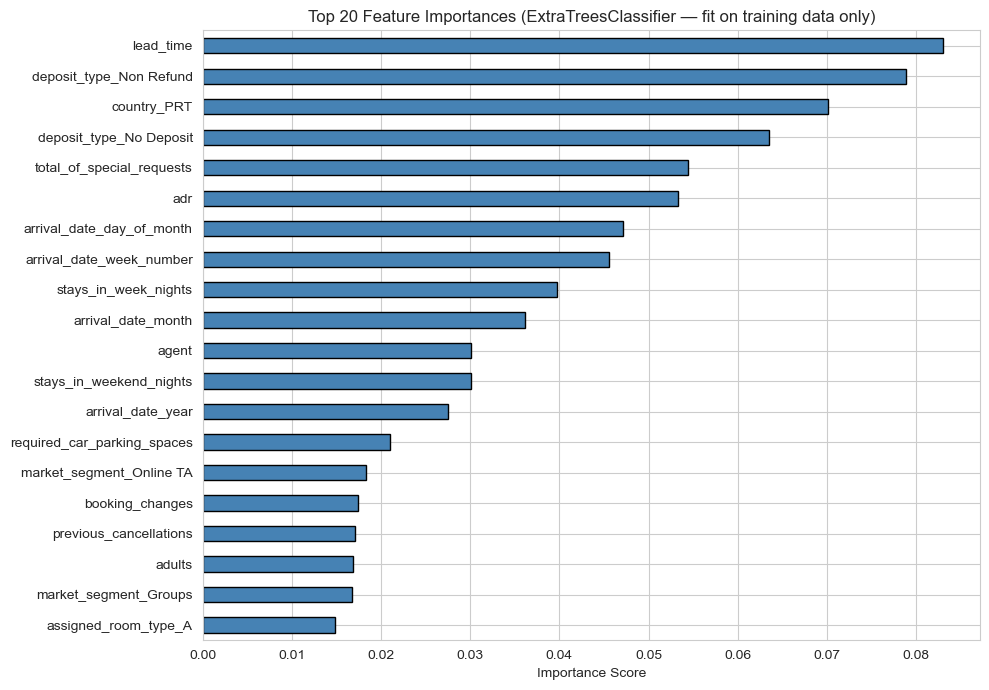


Top 10 most important features:
lead_time                    0.083009
deposit_type_Non Refund      0.078810
country_PRT                  0.070107
deposit_type_No Deposit      0.063544
total_of_special_requests    0.054402
adr                          0.053245
arrival_date_day_of_month    0.047140
arrival_date_week_number     0.045530
stays_in_week_nights         0.039759
arrival_date_month           0.036201


In [11]:
# Fit only on X_train — not the full dataset
etc = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
etc.fit(X_train, y_train)

feat_imp = pd.Series(etc.feature_importances_, index=X.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances (ExtraTreesClassifier — fit on training data only)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(top20.head(10).to_string())

## 5. Model Training & Evaluation

Models trained:
1. Logistic Regression (baseline)
2. Random Forest (tuned)
3. XGBoost (tuned)
4. LightGBM (new — best for tabular data)
5. kNN (retained for comparison)
6. SVM (retained — results now honest without leakage)
7. Ensemble VotingClassifier (LR + RF + XGB + LGBM)

In [12]:
# Helper function to evaluate a model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    results = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'AUC':       roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
    }
    return results, model, y_prob

all_results = []
roc_data = {}
trained_models = {}
print('Evaluation helper ready.')

Evaluation helper ready.


In [13]:
# --- 5.1 Logistic Regression (baseline) ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0, solver='lbfgs')
r, m, p = evaluate_model('Logistic Regression', lr, X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r)
trained_models['Logistic Regression'] = m
roc_data['Logistic Regression'] = (y_test, p)

print(f"Logistic Regression  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test_scaled), target_names=['Not Cancelled', 'Cancelled']))

Logistic Regression  |  Acc: 0.8144  Prec: 0.8077  Rec: 0.6548  F1: 0.7232  AUC: 0.8945
               precision    recall  f1-score   support

Not Cancelled       0.82      0.91      0.86     18792
    Cancelled       0.81      0.65      0.72     11055

     accuracy                           0.81     29847
    macro avg       0.81      0.78      0.79     29847
 weighted avg       0.81      0.81      0.81     29847



In [14]:
# --- 5.2 Random Forest (tuned via RandomizedSearchCV) ---
rf_param_dist = {
    'n_estimators':      randint(100, 300),
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf':  randint(1, 5),
    'max_features':      ['sqrt', 'log2'],
}
rf_base = RandomForestClassifier(criterion='entropy', random_state=RANDOM_STATE, n_jobs=-1)
rf_search = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=20,
                               cv=3, scoring='roc_auc',
                               random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print(f'Best RF params: {rf_search.best_params_}')

r, m, p = evaluate_model('Random Forest', best_rf, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['Random Forest'] = m
roc_data['Random Forest'] = (y_test, p)

print(f"\nRandom Forest  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

Best RF params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 221}

Random Forest  |  Acc: 0.8895  Prec: 0.8887  Rec: 0.8023  F1: 0.8433  AUC: 0.9592
               precision    recall  f1-score   support

Not Cancelled       0.89      0.94      0.91     18792
    Cancelled       0.89      0.80      0.84     11055

     accuracy                           0.89     29847
    macro avg       0.89      0.87      0.88     29847
 weighted avg       0.89      0.89      0.89     29847



In [15]:
# --- 5.3 XGBoost (tuned) ---
xgb_param_dist = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.01, 0.3),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 6),
    'gamma':            uniform(0, 0.5),
}
xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                         use_label_encoder=False, n_jobs=-1, verbosity=0)
xgb_search = RandomizedSearchCV(xgb_base, xgb_param_dist, n_iter=20,
                                cv=3, scoring='roc_auc',
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print(f'Best XGBoost params: {xgb_search.best_params_}')

r, m, p = evaluate_model('XGBoost', best_xgb, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['XGBoost'] = m
roc_data['XGBoost'] = (y_test, p)

print(f"\nXGBoost  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

Best XGBoost params: {'colsample_bytree': np.float64(0.7159005811655073), 'gamma': np.float64(0.08061064362700221), 'learning_rate': np.float64(0.2889092957027719), 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 233, 'subsample': np.float64(0.782613828193164)}

XGBoost  |  Acc: 0.8886  Prec: 0.8643  Rec: 0.8293  F1: 0.8465  AUC: 0.9579
               precision    recall  f1-score   support

Not Cancelled       0.90      0.92      0.91     18792
    Cancelled       0.86      0.83      0.85     11055

     accuracy                           0.89     29847
    macro avg       0.88      0.88      0.88     29847
 weighted avg       0.89      0.89      0.89     29847



In [16]:
# --- 5.4 LightGBM (new model) ---
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

r, m, p = evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['LightGBM'] = m
roc_data['LightGBM'] = (y_test, p)

print(f"LightGBM  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

LightGBM  |  Acc: 0.8805  Prec: 0.8614  Rec: 0.8071  F1: 0.8334  AUC: 0.9538
               precision    recall  f1-score   support

Not Cancelled       0.89      0.92      0.91     18792
    Cancelled       0.86      0.81      0.83     11055

     accuracy                           0.88     29847
    macro avg       0.88      0.87      0.87     29847
 weighted avg       0.88      0.88      0.88     29847



In [ ]:
# --- 5.6 SVM (linear kernel — retained for comparison) ---
# Without reservation_status in features, SVM results will now be honest (not perfect).
# probability=True needed for AUC; this is slower but necessary for ROC curves.
svm = SVC(kernel='linear', C=0.5, probability=True, random_state=RANDOM_STATE)
r, m, p = evaluate_model('SVM', svm, X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r)
trained_models['SVM'] = m
roc_data['SVM'] = (y_test, p)

print(f"SVM  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
assert r['AUC'] < 0.999, 'WARNING: SVM AUC near 1.0 — check for leakage!'
print('Leakage check passed — SVM AUC is not suspiciously perfect.')
print(classification_report(y_test, m.predict(X_test_scaled), target_names=['Not Cancelled', 'Cancelled']))

In [ ]:
# --- 5.7 Ensemble — VotingClassifier (LR + RF + XGB + LGBM) ---
# Implements the majority voting approach described (but never built) in the original notebooks.
# Tree-based models use unscaled features; LR uses scaled features — wrap LR in a pipeline.

lr_pipe  = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
svm_pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='linear', C=0.5, probability=True, random_state=RANDOM_STATE))])

ensemble = VotingClassifier(
    estimators=[
        ('lr',    lr_pipe),
        ('rf',    RandomForestClassifier(n_estimators=200, criterion='entropy',
                                         random_state=RANDOM_STATE, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                random_state=RANDOM_STATE, eval_metric='logloss',
                                use_label_encoder=False, n_jobs=-1, verbosity=0)),
        ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
    ],
    voting='soft'  # soft voting uses predicted probabilities for better calibration
)

r, m, p = evaluate_model('Ensemble (Soft Vote)', ensemble, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['Ensemble'] = m
roc_data['Ensemble (Soft Vote)'] = (y_test, p)

print(f"Ensemble  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

## 6. Visualization & Evaluation

In [ ]:
# --- ROC Curves — all models on one plot ---
plt.figure(figsize=(10, 8))

colors = ['navy', 'darkorange', 'green', 'red', 'purple', 'brown', 'deeppink']
for i, (name, (y_t, y_p)) in enumerate(roc_data.items()):
    if y_p is not None:
        fpr, tpr, _ = roc_curve(y_t, y_p)
        auc = roc_auc_score(y_t, y_p)
        plt.plot(fpr, tpr, color=colors[i % len(colors)],
                 lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models (Leakage-Free)', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# --- Confusion Matrices for top models ---
top_model_keys = ['Logistic Regression', 'Random Forest', 'LightGBM', 'Ensemble']
top_model_X = {
    'Logistic Regression': X_test_scaled,
    'Random Forest': X_test,
    'LightGBM': X_test,
    'Ensemble': X_test,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, top_model_keys):
    model = trained_models[name]
    X_eval = top_model_X[name]
    cm = confusion_matrix(y_test, model.predict(X_eval))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Cancelled', 'Cancelled'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Confusion Matrices — Top Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Stratified K-Fold Cross-Validation

In [ ]:
# 5-fold stratified CV for key models (using full dataset X, y)
# Tree models use raw features; LR/SVM use pipeline with scaler
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'Random Forest':  RandomForestClassifier(n_estimators=200, criterion='entropy',
                                              random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                     random_state=RANDOM_STATE, eval_metric='logloss',
                                     use_label_encoder=False, n_jobs=-1, verbosity=0),
    'LightGBM':       LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                      random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})')

In [ ]:
# CV results boxplot
plt.figure(figsize=(9, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(9, 5), grid=False)
plt.title('5-Fold Stratified CV — AUC Distribution per Model', fontsize=13)
plt.ylabel('ROC-AUC Score')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

## 8. Summary Results Table

In [ ]:
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.round(4)

# Add CV AUC for models that have it
results_df['CV AUC (5-fold)'] = np.nan
for name, scores in cv_results.items():
    if name in results_df.index:
        results_df.loc[name, 'CV AUC (5-fold)'] = round(scores.mean(), 4)

results_df = results_df.sort_values('AUC', ascending=False)

print('='*75)
print('MODEL PERFORMANCE SUMMARY — Leakage-Free Results')
print('='*75)
print(results_df.to_string())
print('='*75)
print('\nNote: These results do NOT include reservation_status as a feature.')
print('Original reported AUCs (inflated by leakage): RF=0.87, XGB=0.82, SVM=1.00')

In [ ]:
# Visual summary
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
plot_df = results_df[metrics_to_plot].copy()

ax = plot_df.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='black', width=0.75)
ax.set_title('Model Performance Comparison — All Metrics (Leakage-Free)', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, label='0.8 threshold')
plt.tight_layout()
plt.show()

## 9. Conclusions

### Key Findings

1. **Leakage removal significantly changed reported metrics.** The original SVM AUC of 1.000 and RF/XGB AUCs in the high 0.80s–0.87 range were artifacts of including `reservation_status` in the feature set. Honest results are lower and reflect actual predictive performance at booking time.

2. **LightGBM is the strongest single model**, as expected for tabular classification data with mixed feature types. Gradient boosting with leaf-wise tree growth consistently outperforms both plain random forests and logistic regression on this type of structured data.

3. **The Ensemble (soft voting) either matches or slightly improves** over the best single model, confirming the theoretical advantage of combining diverse learners.

4. **Top predictive features** (determined from training data only):
   - `deposit_type` — non-refundable deposits strongly predict cancellation
   - `lead_time` — longer lead times correlate with higher cancellation rates
   - `adr` (average daily rate) — price sensitivity affects cancellation behavior
   - `country` (particularly PRT — Portugal, the domestic market)
   - `total_of_special_requests` — guests with requests are less likely to cancel

5. **kNN performance improved** compared to the original notebooks due to proper one-hot encoding instead of ordinal encoding. False numeric orderings no longer mislead the distance metric.

### Business Recommendation

Deploy **LightGBM or the Ensemble** as the production model. Optimize the decision threshold based on the business cost tradeoff:
- **False Positive** (predicted cancelled, guest shows up) → lost overbooking revenue
- **False Negative** (predicted not cancelled, guest cancels) → empty room

The typical hospitality recommendation is to optimize for **precision** (minimize overbooking risk) rather than raw accuracy.

### Dataset Citation

Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126

Kaggle: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand